# Writing a function in python to implement Lagrange interpolation.
## Algorithm to implement the lagrange interpolation

$$
P(x)=\sum_{i=0}^n y(i)Li(x)
$$
$$
Li(x)=\prod_{j=0}^n \frac{(xx-xj)}{(xi-xj)}
$$

### First writing code for sum of numbers

In [31]:
import numpy as np
def lagrng(x, y):
    sum=0
    for i in range(0,6):
        sum=sum+x[i]
    print(sum)

x=np.array([0,1,2,3,4,5])
y=x
lagrng(x,y)

15


### Now writing code for finding the number(coordinate) between the given cordinates

In [32]:
import numpy as np
def lagrng(x,y,n,xx):
    sum=0
    for i in range (0,n):
        product=y[i]
        for j in range(0,n):
            if i!=j:
                product=product*((xx - x[j])/(x[i] - x[j]))
        sum=sum+product
    return sum

x=np.array([0,1,2,3,4,5])
y=np.array([1,3,5,7,9,11])
lagrng(x,y,5,2.5)

np.float64(6.0)

### Now writing the same code for sin(x)

In [33]:
import numpy as np
def lagrng(x,y,n,xx):
    sum=0
    for i in range (0,n):
        product=y[i]
        for j in range(0,n):
            if i!=j:
                product=product*((xx - x[j])/(x[i] - x[j]))
        sum=sum+product
    return sum

x=np.array([0,np.pi/6, np.pi/4, np.pi/3, np.pi/2, np.pi])
y=np.sin(x)
lagrng(x,y,len(x),np.pi)

np.float64(1.2246467991473532e-16)

### Comparing the algorithm with the lagrange function
#### now here for same value of x=pi/6 both gives the same value of 0.4999... upto 14 decimal places

In [34]:
result1=lagrng(x, y, len(x), np.pi/6)
print(result1)
poly = lagrange(x, y)
result2=poly(np.pi/6)
print(result2)

0.49999999999999994
0.4999999999999987


C:\Users\patil\AppData\Local\Temp\ipykernel_20004\3736986862.py:3: DeprecationWarning: `lagrange` is deprecated and will be removed in SciPy 1.20.0. Use `scipy.interpolate.BarycentricInterpolator` instead.
  poly = lagrange(x, y)


#### Now trying to create a random value selection for (m= maximum camber), (p= camber location) and (t= maximum thickness)

In [35]:
m=np.random.uniform(0.01, 0.06)               ## realistic range of maximum camber for cambered airfoil
print("maximum camber(m):", m)

p=np.random.uniform(0.15, 0.60)               ## realistic range of camber location for cambered airfoil
print("camber location(p):", p)

t=np.random.uniform(0.06, 0.18)               ## realistic range of maximum thickness for cambered airfoil
print("maximum thickness(t):", t)

maximum camber(m): 0.0596167543011919
camber location(p): 0.2936514356939963
maximum thickness(t): 0.13321510748942655


# Now defing the NACA 4 digit Airfoil for point generation

In [66]:
import matplotlib.pyplot as plt
def naca_4digit(m,p,t,n=200, x=None):
    if x is None:
        x=np.linspace(0,1,n)

    yt= 5*t*(0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)  #thickness distribution
    yc=np.where( x<p, 
             m/p**2 * (2*p*x - x**2),
             m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))
    yu=yc + yt
    yl=yc - yt
    return x,yu,yl,yc

In [67]:
xtrue, yutrue, yltrue, yctrue = naca_4digit(m, p, t, n=500)          ## for actual true curve
x, yu, yl, yc= naca_4digit(m, p, t, n=12)                            ## for sparse points on curve

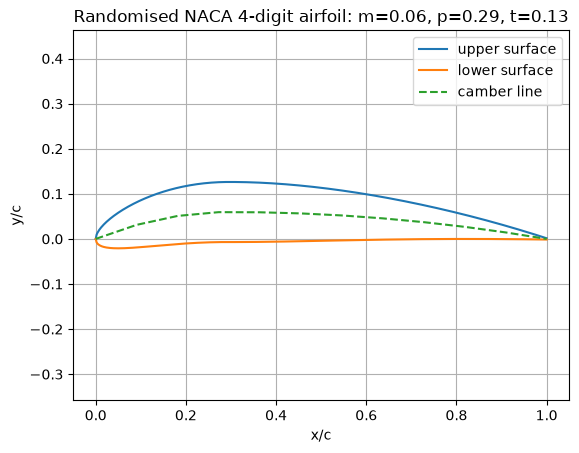

In [68]:
plt.plot(xtrue,yutrue, label="upper surface")
plt.plot(xtrue,yltrue, label="lower surface")
plt.plot(x,yc,'--', label="camber line")
plt.legend()
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.axis("equal")
plt.title(f"Randomised NACA 4-digit airfoil: m={m:.2f}, p={p:.2f}, t={t:.2f}")      ## f here tells to look inside the string and replace them with actual variable and , :.2f also spectifies the no. of decimal places to shoe
plt.grid(True)
plt.show()

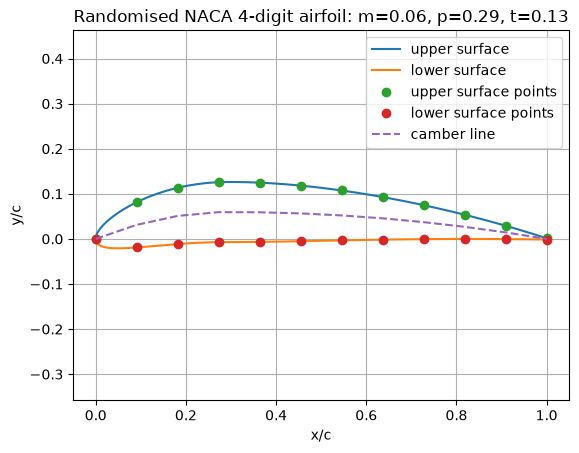

In [69]:
plt.plot(xtrue,yutrue, label="upper surface")
plt.plot(xtrue,yltrue, label="lower surface")
plt.plot(x,yu, 'o', label="upper surface points")
plt.plot(x,yl, 'o', label="lower surface points")
plt.plot(x,yc,'--', label="camber line")
plt.legend()
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.axis("equal")
plt.title(f"Randomised NACA 4-digit airfoil: m={m:.2f}, p={p:.2f}, t={t:.2f}")      ## f here tells to look inside the string and replace them with actual variable and , :.2f also spectifies the no. of decimal places to shoe
plt.grid(True)
plt.show()

## Example

In [70]:
numbers=[1,2,3,4,5]
squares=[]

for n in numbers :
    result = n**2
    squares.append(result)
print(squares)

[1, 4, 9, 16, 25]


## Now storing the output

In [71]:
y_new_upper = []
for xx in xtrue:                                      ## xx takes each value from xtrue
    result=(lagrng(x, yu, len(x), xx))                ## compute 1 new y value at this xx
    y_new_upper.append(result)                        ## store that y value in the list

y_new_lower = []
for xx in xtrue:                                      ## xx takes each value from xtrue
    result=(lagrng(x, yl, len(x), xx))                ## compute 1 new y value at this xx
    y_new_lower.append(result)                        ## store that y value in the list

In [72]:
print(y_new_upper [0])
print(y_new_lower [0])
print(yutrue [0])

0.0
0.0
0.0


In [73]:
mid = len(xtrue) // 2                 ## checking the value of y_new_upper nad yutrue and the midpoint
print(y_new_upper[mid])
print(yutrue[mid])
print(y_new_lower[mid])
print(yltrue[mid])

0.11321297394337751
0.11317940783792405
-0.004191828758715235
-0.004220634725932183


# Now generating all 3 graphs in one, that is with actual curve,  the sparse points and the new generated points 

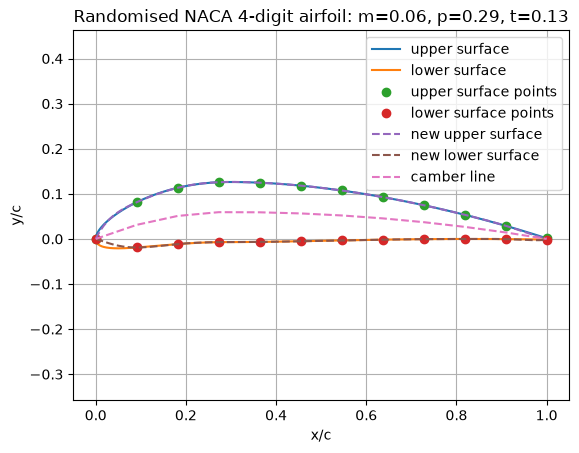

In [74]:
plt.plot(xtrue,yutrue, label="upper surface")
plt.plot(xtrue,yltrue, label="lower surface")
plt.plot(x,yu, 'o', label="upper surface points")
plt.plot(x,yl, 'o', label="lower surface points")
plt.plot(xtrue,y_new_upper, '--', label="new upper surface")
plt.plot(xtrue,y_new_lower, '--', label="new lower surface")
plt.plot(x,yc,'--', label="camber line")
plt.legend()
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.axis("equal")
plt.title(f"Randomised NACA 4-digit airfoil: m={m:.2f}, p={p:.2f}, t={t:.2f}")      ## f here tells to look inside the string and replace them with actual variable and , :.2f also spectifies the no. of decimal places to shoe
plt.grid(True)
plt.show()

# Now calculating error
#### Now as we have y_new_upper and y_new_lower in the list and yutrur , yltrue in the numpy.ndarray format, we cant directly subtract it to find the error


In [75]:
type(yutrue)

numpy.ndarray

In [76]:
type(y_new_upper)

list

In [77]:
y_new_upper=np.array(y_new_upper)           ## converting list into numpy array
y_new_lower=np.array(y_new_lower)

In [78]:
error_upper = yutrue - y_new_upper
          
error_lower = yltrue - y_new_lower


max_error_upper=np.max(abs(error_upper))         ## getting the absolute value as there can be both positive and negative value of error
print(f"max_error_upper={max_error_upper}")

max_error_lower=np.max(abs(error_lower))
print(f"max_error_lower={max_error_lower}")

max_error_upper=0.005983527888184097
max_error_lower=0.012042105211337037


### now to calculate error using RMS
$$
RMS=\sqrt \frac{1}{n} \sum_{i=1}^n error_i^2
$$

In [79]:
rms_error_upper=np.sqrt(np.mean(error_upper**2))
print(f"RMS_error_upper={rms_error_upper}")
rms_error_lower=np.sqrt(np.mean(error_lower**2))
print(f"RMS_error_lower={rms_error_lower}")

RMS_error_upper=0.0008297368991286472
RMS_error_lower=0.0023189378589296146


# How can you improve your results by choosing spacing between data points?
### As in this report we have selected n=12 , so there are 12 sparse points evenly spread out over the upper curve as well as lower curve.
### But the curve is too steep near the leading edge and flat near the trailing edge, so it does not take this into consideration.

#### Thatswhy using cosine spaceing to generate more points near leading edge so it can capture the steepness of the airfoil.

In [80]:
theta = np.linspace(0, np.pi, 12)
x_cos = (1 - np.cos(theta)) / 2

x_cos, yu_cos, yl_cos, yc_cos = naca_4digit(m, p, t, x=x_cos)
print(x_cos)

[0.         0.02025351 0.07937323 0.17256963 0.29229249 0.42884258
 0.57115742 0.70770751 0.82743037 0.92062677 0.97974649 1.        ]


### So here as we can see the points have small gaps near the leading edge , large gap in middle and again small gaps near trailing edge.

In [81]:
## now creating new lagrange for the cos spacing
y_new_upper_cos = []
for xx in xtrue:                                  
    result=(lagrng(x_cos, yu_cos, len(x_cos), xx))                
    y_new_upper_cos.append(result)   
y_new_upper_cos=np.array(y_new_upper_cos)

y_new_lower_cos = []
for xx in xtrue:                                    
    result=(lagrng(x_cos, yl_cos, len(x_cos), xx))                
    y_new_lower_cos.append(result)                        
y_new_lower_cos=np.array(y_new_lower_cos)

In [83]:
## now calculating error using cosine spacing
error_upper_cos= yutrue - y_new_upper_cos
error_lower_cos= yltrue - y_new_lower_cos

max_error_upper_cos=np.max(np.abs(error_upper_cos))
max_error_lower_cos=np.max(np.abs(error_lower_cos))

rms_error_upper_cos=np.sqrt(np.mean(error_upper_cos**2))
rms_error_lower_cos=np.sqrt(np.mean(error_lower_cos**2))

print(f"Max_error_upper_cos={max_error_upper_cos}")
print(f"Max_error_lower_cos={max_error_lower_cos}")
print(f"RMS_error_upper_cos={rms_error_upper_cos}")
print(f"RMS_error_lower_cos={rms_error_lower_cos}")

Max_error_upper_cos=0.00530770872508898
Max_error_lower_cos=0.005318972330012971
RMS_error_upper_cos=0.0007951462725629295
RMS_error_lower_cos=0.0009360778857217425


### Reconstructing the same n=12 points with cosine spacing reduced the maximum error on the lower surface (0.0120 to 0.0053) almost 56 % error reduction. And RMS error also improved slightly.
### So by this we can say that the location of interpolation points matter, which can significantly affect the accuracy of the curve, particularly in the region of high curvature such as leading edge.